In [2]:
import pandas as pd
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

In [3]:
df = pd.read_csv("styles.csv", on_bad_lines='skip')

print(df.shape)
df.head()

(44424, 10)


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [4]:
df = df.dropna(subset=['usage', 'baseColour', 'season', 'productDisplayName'])

df['year'] = df['year'].fillna(0).astype(int)

df = df.reset_index(drop=True)

In [5]:
valid_items = ['Tshirts', 'Shirts', 'Jeans', 'Trousers', 'Shorts']

transactions = df.groupby(['gender', 'usage'])['articleType'] \
    .apply(lambda x: list(set([i for i in x if i in valid_items])))

transactions = transactions.tolist()

In [6]:
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

df_apriori = pd.DataFrame(te_array, columns=te.columns_)

frequent_itemsets = apriori(df_apriori, 
                           min_support=0.05, 
                           max_len=2, 
                           use_colnames=True)

rules = association_rules(frequent_itemsets, 
                          metric="confidence", 
                          min_threshold=0.3)

In [7]:
df['text'] = df['articleType'] + " " + df['baseColour'] + " " + df['usage']

tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['text'])

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

# Helper Functions

🔹 Image Display


In [8]:
def show_results(title, data):
    print(f"\n🔹 {title}")
    
    plt.figure(figsize=(12,4))

    for i, idx in enumerate(data.index):
        img_id = df.loc[idx, 'id']
        path = f"images/{img_id}.jpg"

        if os.path.exists(path):
            img = cv2.imread(path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            plt.subplot(1, len(data), i+1)
            plt.imshow(img)
            plt.title(df.loc[idx, 'articleType'])
            plt.axis('off')

    plt.show()

In [9]:
def recommend_outfit(item_name, rules):
    rec = []

    for _, row in rules.iterrows():
        if item_name in row['antecedents']:
            rec.extend(list(row['consequents']))

    return list(set(rec))

In [10]:
def get_similar_indices(index, top_n=5):
    sim_scores = list(enumerate(cosine_sim[index]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:top_n+1]
    
    return [i[0] for i in sim_scores]

# Smart Input System


In [43]:
def normalize_input(user_input):
    user_input = user_input.lower().strip()

    words = user_input.split()
    new_words = []

    for w in words:
        if w == "pents":
            new_words.append("pants")
        elif w == "pant":
            new_words.append("pants")
        elif w == "watchs":
            new_words.append("watches")
        elif w in ["t-shirt", "tshirt", "tshirts", "t"]:
            new_words.append("tshirts")
        else:
            new_words.append(w)

    return " ".join(new_words)

In [44]:
item_map = {
    "tshirt": ["Tshirts"],
    "tshirts": ["Tshirts"],
    "shirt": ["Shirts"],
    "shirts": ["Shirts"],
    "top": ["Tops"],
    "tops": ["Tops"],

    "pants": ["Jeans", "Trousers", "Track Pants"],
    "jeans": ["Jeans"],
    "trouser": ["Trousers"],
    "trousers": ["Trousers"],

    "shorts": ["Shorts"],
    "short": ["Shorts"],

    "shoe": ["Casual Shoes"],
    "shoes": ["Casual Shoes"],
    "sandals": ["Sandals"],

    "watch": ["Watches"],
    "watches": ["Watches"],

    "belt": ["Belts"],
    "belts": ["Belts"],

    "bag": ["Handbags"],
    "bags": ["Handbags"],

    "sunglasses": ["Sunglasses"],

    "dress": ["Dresses"],
    "dresses": ["Dresses"],

    "skirt": ["Skirts"],
    "skirts": ["Skirts"]
}

In [45]:
def parse_input(user_input):
    user_input = normalize_input(user_input)
    words = user_input.split()

    color = None
    items = []
    gender = None

    # color detect
    for c in df['baseColour'].dropna().unique():
        if c.lower() in user_input:
            color = c
            break

    # item detect
    for w in words:
        if w in item_map:
            items.extend(item_map[w])

    # fallback
    if not items:
        for i in df['articleType'].unique():
            if i.lower() in user_input:
                items.append(i)

    # gender detect
    # 🔥 CORRECT ORDER + EXACT MATCH
    if "women" in user_input or "woman" in user_input:
        gender = "Women"
    elif "men" in user_input or "man" in user_input:
        gender = "Men"
    elif "girl" in user_input:
        gender = "Girls"
    elif "boy" in user_input:
        gender = "Boys"

    return color, list(set(items)), gender

In [46]:
def smart_recommend_full(user_input, top_n=5):

    color, items, gender = parse_input(user_input)

    data = df.copy()

    # gender filter
    if gender:
        data = data[data['gender'] == gender]

        # item filter (IMPORTANT FIX)
    # 🔥 STRICT ITEM FILTER
    if items:
        data = data[data['articleType'].isin(items)]

    # ❗ EXTRA SAFETY (VERY IMPORTANT)
    if items:
        data = data[data['articleType'].apply(lambda x: x in items)]

    # color filter
    if color:
        data = data[data['baseColour'] == color]

    if data.empty:
        print("❌ No results found")
        return None

    return data.head(top_n)

In [47]:
def show_results(title, data):
    print("\n" + "="*50)
    print(title)
    print("="*50)

    plt.figure(figsize=(12,4))

    for i, idx in enumerate(data.index):
        row = data.loc[idx]
        path = f"images/{row['id']}.jpg"

        print(f"{i+1}. {row['productDisplayName']}")

        if os.path.exists(path):
            img = cv2.imread(path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            plt.subplot(1, len(data), i+1)
            plt.imshow(img)
            plt.title(row['articleType'])
            plt.axis('off')

    plt.show()

In [48]:
def run_system():
    while True:
        user_input = input("\nEnter search (or exit): ")

        if user_input.lower() == "exit":
            print("Bye 👋")
            break

        results = smart_recommend_full(user_input)

        if results is not None:
            show_results(f"Results for: {user_input}", results)

In [49]:
# def run_system():
#     while True:
#         user_input = input("\nEnter your query (or 'exit'): ")

#         if user_input.lower() == "exit":
#             print("Exiting...")
#             break

#         primary, secondary = smart_recommend_full(user_input)

#         if primary is None:
#             continue

#         print("\n==============================")
#         print(f"INPUT: {user_input}")
#         print("==============================")

#         show_results("Top Matches", primary)

#         if secondary is not None and not secondary.empty:
#             show_results("Similar Items", secondary)


Results for: red shoes
1. ID Men Red Shoes
2. Rockport Men LLandro Red Casual Shoes
3. Basics Men Red Casual Shoes
4. Fila Men Leonard Red Shoes
5. Footfun Kids Unisex Red Shoes


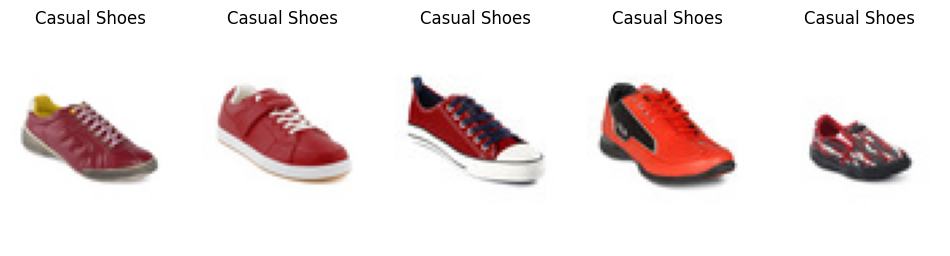


Results for: white shoes
1. Gas Men Europa White Shoes
2. Nike Men Air Rift MTR White Casual Shoe
3. Numero Uno Men White Casual Shoes
4. Nike Men White Capri II Casual Shoe
5. Numero Uno Men White Shoes


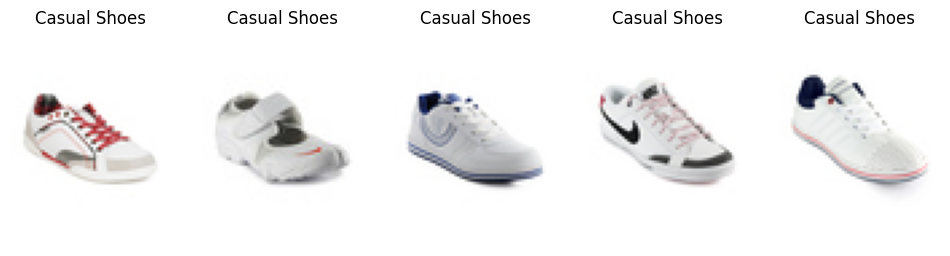

Bye 👋


In [51]:
run_system()